In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam

I:\SNAKS\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 [==============================] - 34s 0us/step


In [3]:
class_names = [ 'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

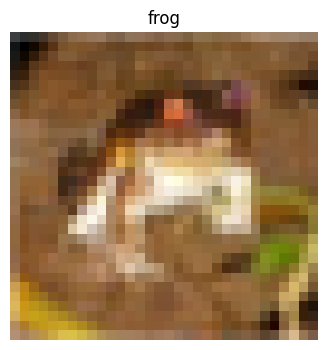

In [8]:
plt.figure(figsize=(4,4))
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
y_train = y_train.flatten()
y_test = y_test.flatten()


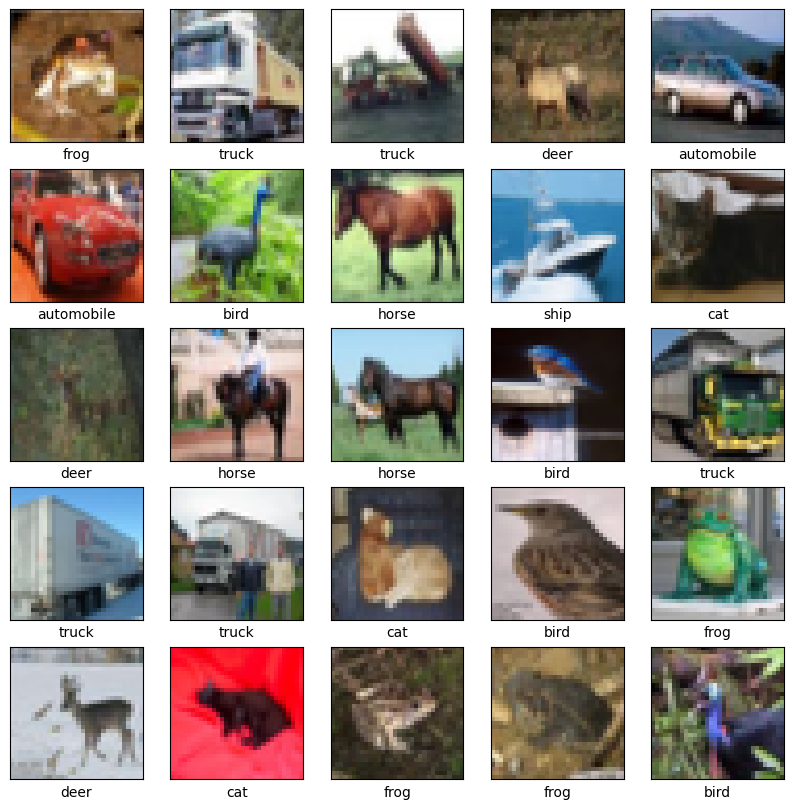

In [11]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])

    plt.imshow(x_train[i])

    plt.xlabel(class_names[y_train[i]])

plt.show()

In [20]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(4096, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(2048, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

In [21]:
model.compile(optimizer=Adam(learning_rate=0.0005),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 3072)              0         
                                                                 
 dense_4 (Dense)             (None, 4096)              12587008  
                                                                 
 batch_normalization (BatchN  (None, 4096)             16384     
 ormalization)                                                   
                                                                 
 dropout_2 (Dropout)         (None, 4096)              0         
                                                                 
 dense_5 (Dense)             (None, 2048)              8390656   
                                                                 
 batch_normalization_1 (Batc  (None, 2048)             8192      
 hNormalization)                                      

In [23]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
313/313 [==============================] - 37s 114ms/step - loss: 2.1771 - accuracy: 0.2838 - val_loss: 1.8873 - val_accuracy: 0.3183
Epoch 2/100
313/313 [==============================] - 36s 115ms/step - loss: 1.8486 - accuracy: 0.3555 - val_loss: 1.7919 - val_accuracy: 0.3475
Epoch 3/100
313/313 [==============================] - 43s 137ms/step - loss: 1.6951 - accuracy: 0.4010 - val_loss: 1.9036 - val_accuracy: 0.3382
Epoch 4/100
313/313 [==============================] - 37s 118ms/step - loss: 1.6178 - accuracy: 0.4191 - val_loss: 1.8839 - val_accuracy: 0.3335
Epoch 5/100
313/313 [==============================] - 36s 116ms/step - loss: 1.5646 - accuracy: 0.4388 - val_loss: 1.6630 - val_accuracy: 0.3898
Epoch 6/100
313/313 [==============================] - 36s 117ms/step - loss: 1.5361 - accuracy: 0.4530 - val_loss: 1.7088 - val_accuracy: 0.3752
Epoch 7/100
313/313 [==============================] - 38s 122ms/step - loss: 1.5265 - accuracy: 0.4540 - val_loss: 1.6406 -

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 [==============================] - 3s 9ms/step - loss: 1.3130 - accuracy: 0.5432
Test accuracy: 0.5432000160217285


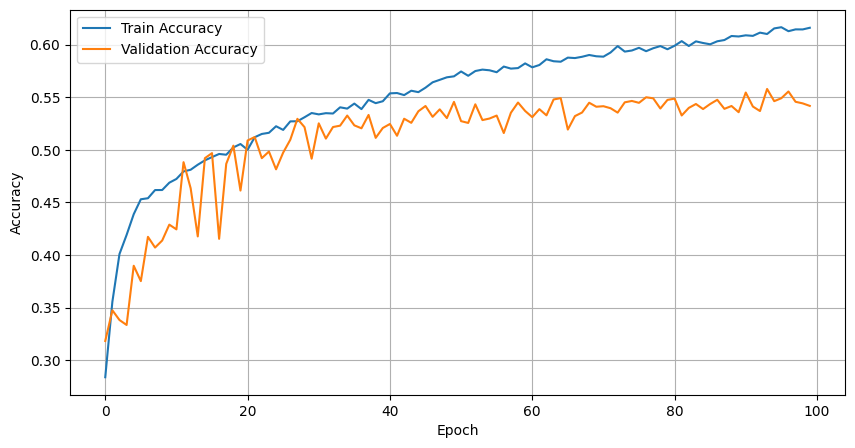

In [25]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [26]:
predictions = model.predict(x_test)

313/313 [==============================] - 3s 10ms/step


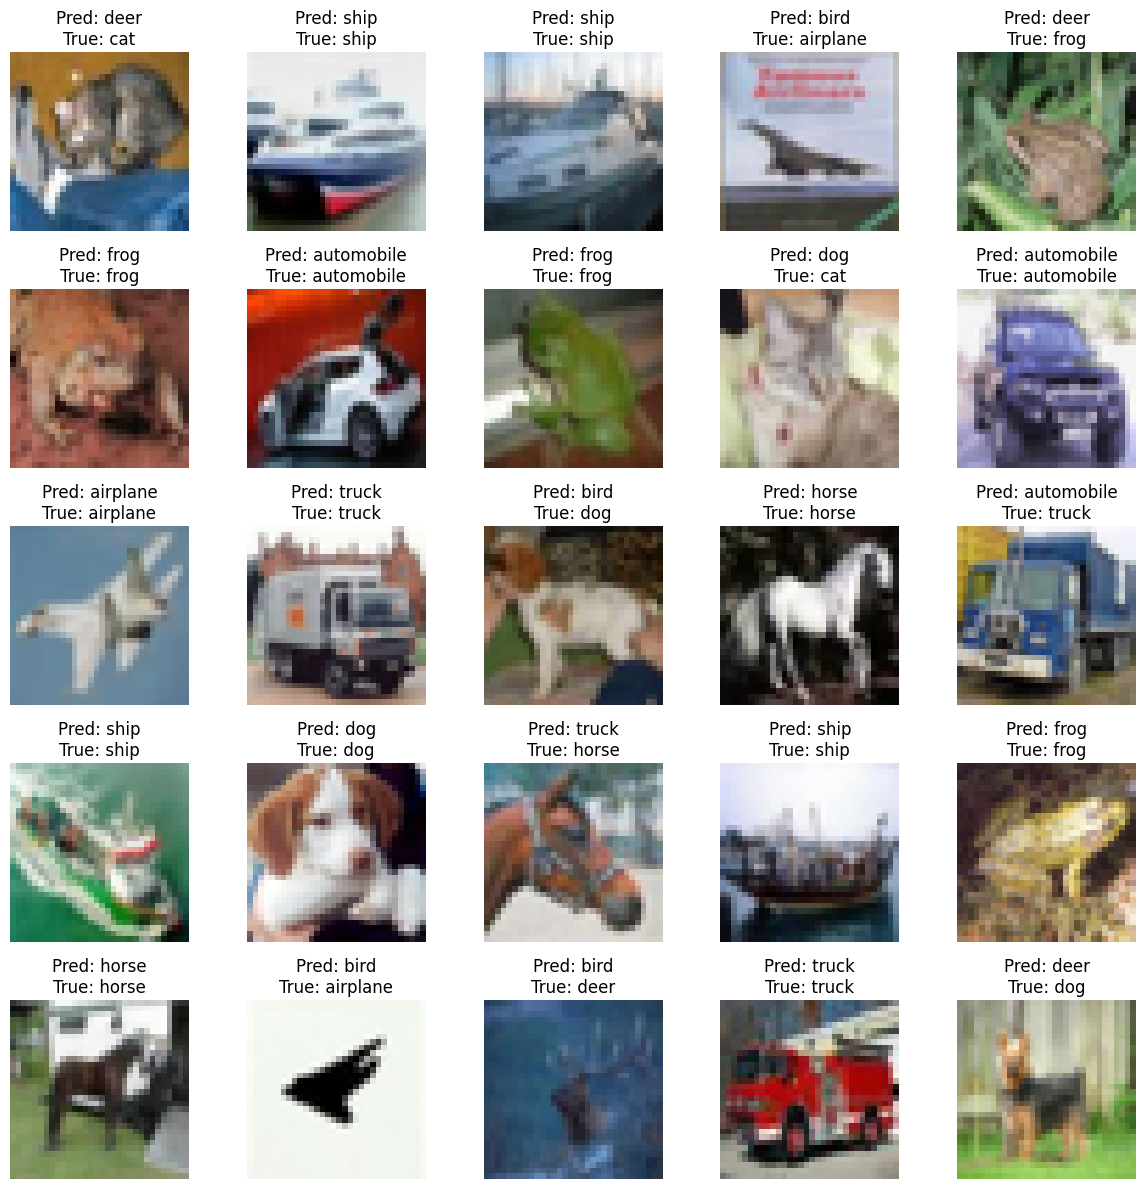

In [29]:
plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i])
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f'Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}')
    plt.axis('off')

plt.tight_layout()
plt.show()